# Stage 7: impact analysis (D040-D041)

Display only. Run `make all` first; this notebook reads `reports/`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.config import load_config

cfg = load_config()
T, F = cfg["paths"]["tables"], cfg["paths"]["figures"]
pd.set_option("display.width", 200)


def show(name):
    plt.figure(figsize=(12, 5))
    plt.imshow(mpimg.imread(F / name))
    plt.axis("off")
    plt.show()

In [2]:
pd.read_csv(T / "impact_bridge.csv")

,step,share_exposure_moving_gt_5pct,share_exposure_moving_gt_20pct,mean_abs_change
0,1. GLM-A -> GLM-A-mono (BonusMalus constraint),0.085336,0.000000,0.017085
1,2. GLM-A-mono -> GLM-B (interactions),0.653080,0.113037,0.095784
2,total: GLM-A -> GLM-B,0.676646,0.123687,0.100695


In [3]:
pd.read_csv(T / "impact_change_bands.csv")

,change_band,policies,exposure,mean_change,share_policies,share_exposure,holdout_exposure,holdout_claims,observed_capped_loaded,observed_all_claims,current_premium,proposed_premium,observed_over_current,observed_over_proposed,all_claims_over_current,all_claims_over_proposed,ae_rel_halfwidth_95
0,< -20%,27842,12157.542869,-0.291474,0.041065,0.033927,2384.958572,223,4.630535e+05,347752.72,6.024096e+05,4.115977e+05,0.768669,1.125015,0.577270,0.844885,0.131251
1,-20% to -10%,93864,58889.588038,-0.138254,0.138444,0.164338,11618.375500,603,1.281856e+06,1736156.72,1.636950e+06,1.412807e+06,0.783076,0.907312,1.060604,1.228871,0.079817
2,-10% to -5%,79530,43101.681109,-0.066345,0.117302,0.120280,8691.758689,688,1.507150e+06,1394223.74,1.507048e+06,1.402380e+06,1.000068,1.074709,0.925136,0.994184,0.074724
3,-5% to +5%,220298,124316.615970,-0.016437,0.324928,0.346920,25153.028522,1725,3.458494e+06,3119121.07,3.724286e+06,3.684212e+06,0.928633,0.938734,0.837509,0.846618,0.047191
4,+5% to +10%,111590,56413.823144,0.075498,0.164589,0.157429,11314.049007,897,2.144873e+06,1896755.66,1.673042e+06,1.797275e+06,1.282020,1.193403,1.133717,1.055351,0.065442
5,+10% to +20%,76752,35115.610170,0.131765,0.113205,0.097994,7048.602347,648,1.379827e+06,5220374.43,1.146345e+06,1.304234e+06,1.203676,1.057960,4.553931,4.002637,0.076996
6,> +20%,68115,28348.634163,0.260713,0.100466,0.079110,5617.972719,565,1.130562e+06,978752.40,9.873486e+05,1.268910e+06,1.145048,0.890971,0.991294,0.771333,0.082458


In [4]:
pd.read_csv(T / "impact_top_segments.csv")

,segment,exposure,policies,mean_change,holdout_observed_over_current,holdout_claims
0,BonusMalus_band=100-110 & VehBrand_grp=B12,1705.154934,5201,-0.316447,0.400817,32
1,DrivAge_band=27-29 & BonusMalus_band=51-55,1391.906645,2165,-0.291376,0.461814,10
2,BonusMalus_band=91-99 & VehBrand_grp=B12,1277.082894,3478,-0.285661,0.918516,20
3,BonusMalus_band=100-110 & Region_grp=Centre,1569.057095,4645,0.252089,1.494132,92
4,BonusMalus_band=81-90 & VehBrand_grp=B12,2840.760988,7807,-0.218662,1.018443,50
5,DrivAge_band=55-64 & BonusMalus_band=61-65,1501.806951,2878,0.214815,1.031985,52
6,DrivAge_band=25-26 & VehBrand_grp=B12,1399.497507,4028,-0.207521,0.841384,30
7,DrivAge_band=27-29 & BonusMalus_band=56-60,2960.689945,5654,-0.201062,0.733359,28
8,BonusMalus_band=76-80 & VehBrand_grp=B12,3248.937999,9113,-0.181981,0.797844,52
9,BonusMalus_band=91-99 & Region_grp=Centre,1846.241175,4250,0.180585,1.058458,63


In [5]:
pd.read_csv(T / "impact_capping.csv")

,option,total_premium,revenue_vs_current,share_of_premium_movement_delivered,holdout_gini_capped_loss,share_of_gini_improvement_retained,share_exposure_at_cap,rebalance_factor
0,current,5.649351e+07,0.000000e+00,0.000000,0.317833,0.000000,NaN,NaN
1,proposed (uncapped),5.649351e+07,0.000000e+00,1.000000,0.327974,1.000000,0.177565,NaN
2,"capped +/-15%, not rebalanced",5.632280e+07,-3.021777e-03,0.788554,0.328464,1.048346,0.177565,NaN
3,"capped +/-15%, rebalanced",5.649351e+07,-3.141931e-14,0.785896,0.328490,1.050892,0.170984,1.00388


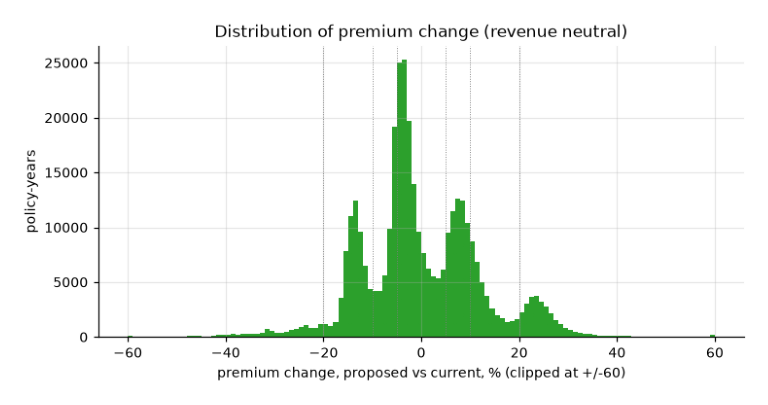

In [6]:
show("impact_change_histogram.png")